In [4]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [5]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    project_dir = r'C:\Users\jmora\Documents\TFMDS'
    os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", project_dir in sys.path)

Directorio de trabajo: C:\Users\jmora\Documents\TFMDS
Python path incluye proyecto: True


## Lectura de fichero y adaptación de los tipos


# CatBoost

- Determinar características utilizar FEATURES
- Descomponer serie en Train y Test
- Características a Normalizar/Estandarizar o codificar
- Crear modelos estimando hiperparámetros
- Valorar modelos




# CatBoost global

In [6]:


import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


c:\Users\jmora\Documents\TFMDS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  lag_ventas_1        625800 non-null  float64       
 12  lag_ventas_2        625800 non-null  fl

In [8]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [9]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST


In [10]:

# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (CatBoost)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: CATBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")

print("\n🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA CATBOOST
# =====================================================

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...")
start_time = time.perf_counter()

study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=40, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros CatBoost:")
print(study_catboost.best_params)

best_params = study_catboost.best_params.copy()
best_params.update({
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False
})

best_catboost = CatBoostRegressor(**best_params)

best_catboost.fit(X_train, y_train, verbose=False)

# Predicciones
y_train_pred = best_catboost.predict(X_train)
y_test_pred = best_catboost.predict(X_test)

# Calcular métricas
metricas_train_global = calcular_metricas(y_train, y_train_pred, 'CatBoost Global Train')
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'CatBoost Global Test')

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_train_global, metricas_test_global])


[I 2025-11-28 12:47:57,652] A new study created in memory with name: no-name-db5721bd-18e0-41db-8d1f-818926b78cc4



🔍 MODELO 1: CATBOOST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...

🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...


[I 2025-11-28 12:48:07,366] Trial 0 finished with value: 3.8817080197742984 and parameters: {'iterations': 364, 'learning_rate': 0.2426123232765291, 'depth': 9, 'l2_leaf_reg': 8.641138607744033, 'bagging_temperature': 0.5749234811446419, 'random_strength': 1.109568301752375, 'border_count': 136, 'min_data_in_leaf': 31}. Best is trial 0 with value: 3.8817080197742984.
[I 2025-11-28 12:48:24,046] Trial 1 finished with value: 3.8872252533323426 and parameters: {'iterations': 505, 'learning_rate': 0.1902758847992516, 'depth': 4, 'l2_leaf_reg': 2.381033560124585, 'bagging_temperature': 0.6329082758400835, 'random_strength': 8.283481453066617, 'border_count': 185, 'min_data_in_leaf': 48}. Best is trial 0 with value: 3.8817080197742984.
[I 2025-11-28 12:48:39,341] Trial 2 finished with value: 3.891370008891481 and parameters: {'iterations': 606, 'learning_rate': 0.08046421840901075, 'depth': 8, 'l2_leaf_reg': 6.351888249616327, 'bagging_temperature': 0.9034909740234871, 'random_strength': 1.8

✅ Optuna completado en 772.99 segundos

🏆 Mejores hiperparámetros CatBoost:
{'iterations': 1106, 'learning_rate': 0.21732884288065077, 'depth': 9, 'l2_leaf_reg': 6.025399199341219, 'bagging_temperature': 0.6141347550819385, 'random_strength': 1.6770895022016519, 'border_count': 45, 'min_data_in_leaf': 76}

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Global Train 1.5349 4.9587 2.2268 0.3913     45.69     138.70 0.6453    88.78
 CatBoost Global Test 1.5821 5.8072 2.4098 0.2422     50.62     145.17 0.7385    96.89

🏆 Mejor modelo: CatBoost Global Train (RMSE: 2.2268)


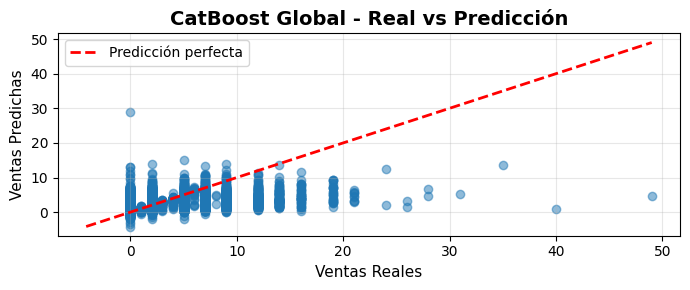

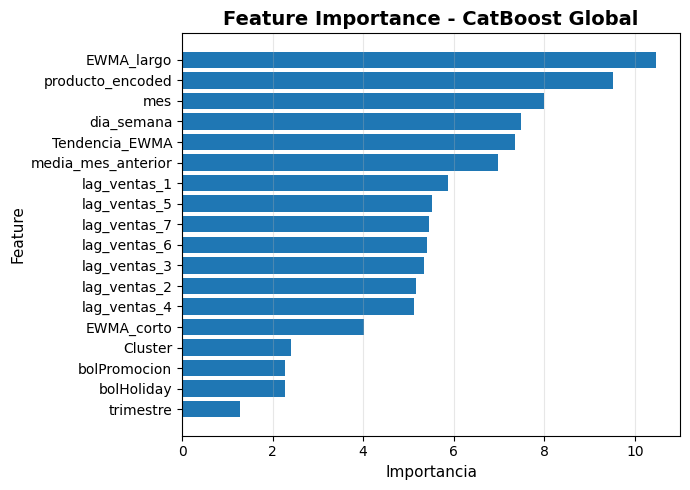

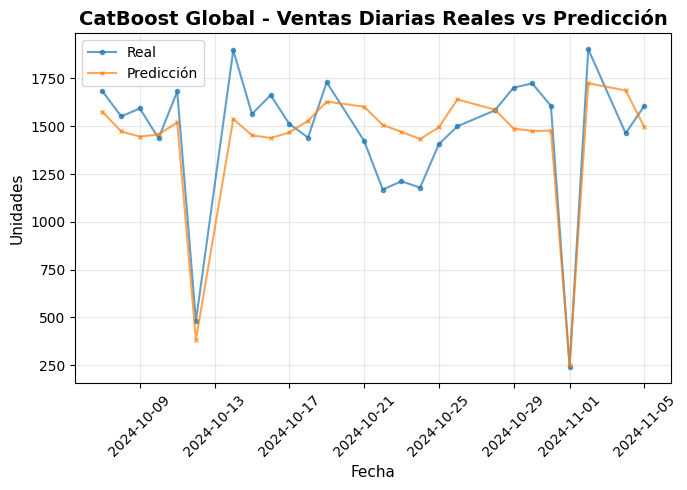

In [11]:

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]

grafico_scatter_prediccion(
    df=df_test_viz,
    col_real=TARGET,
    col_pred='prediccion',
    titulo='CatBoost Global - Real vs Predicción',
    figsize=(7, 3)
)

grafico_feature_importance(
    modelo=best_catboost,
    feature_names=FEATURES,
    top_n=len(FEATURES),
    titulo='Feature Importance - CatBoost Global',
    figsize=(7, 5)
)

# Crear dataframe con suma por día
df_daily = df_test_viz.copy()
df_daily['fecha'] = df_daily['idSecuencia'].dt.date
df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
grafico_real_vs_prediccion(
    df=df_daily_sum,
    col_real=TARGET,
    col_pred='prediccion',
    col_fecha='fecha',
    titulo='CatBoost Global - Ventas Diarias Reales vs Predicción',
    figsize=(7, 5)
)



🔍 MODELO 2: CATBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...
   ✓ MAE: 1.84 | RMSE: 2.59 | R²: 0.0896


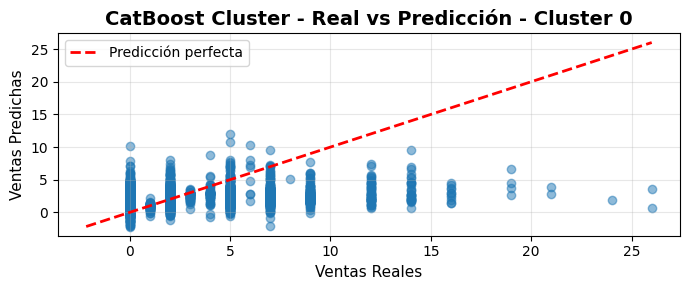

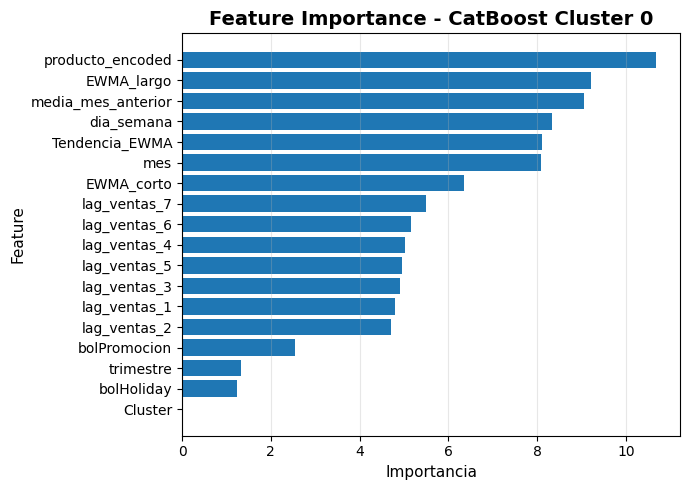

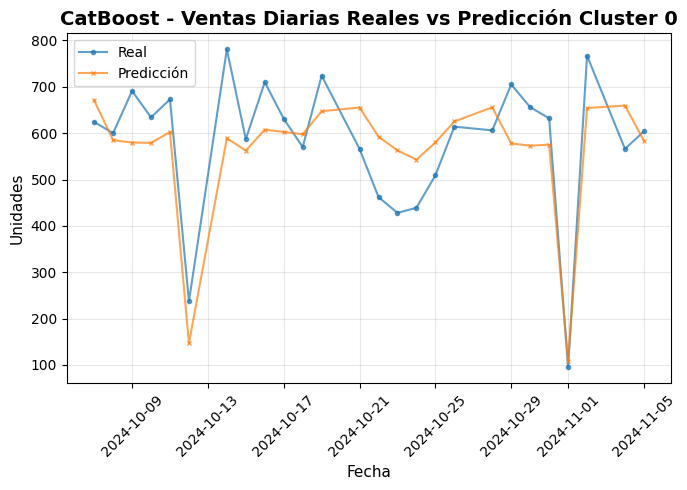


   📌 Producto representativo: 17 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.05
      Error abs medio:          1.84
      Error máximo:            25.36


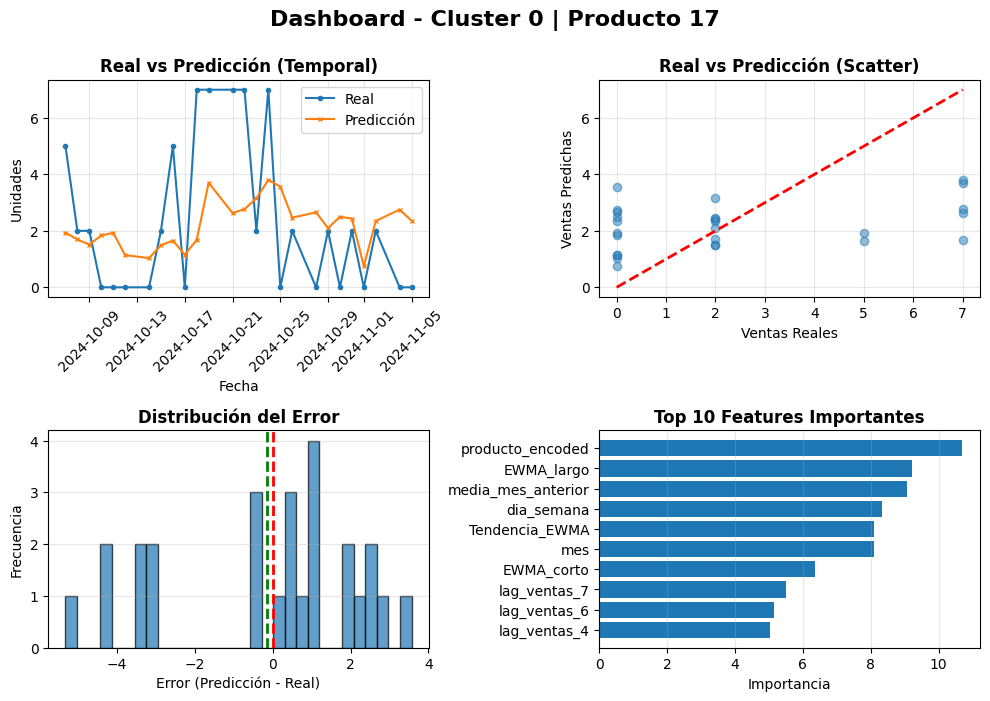


🔄 Entrenando modelo para Cluster 1...
   ✓ MAE: 2.91 | RMSE: 3.77 | R²: 0.0550


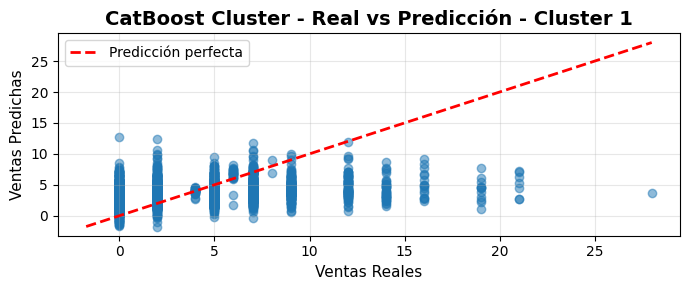

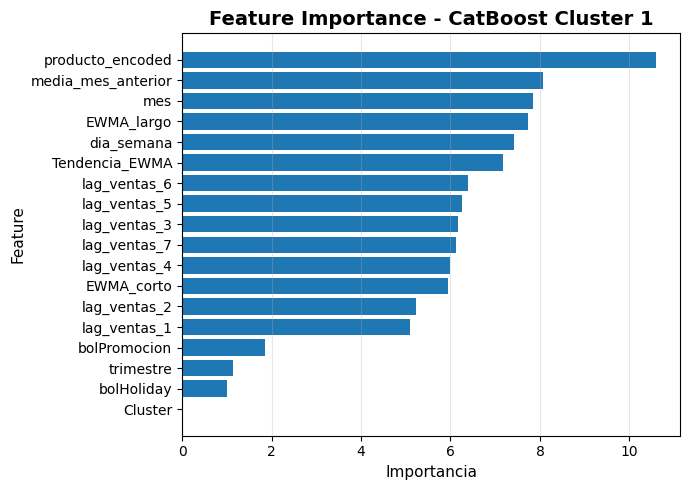

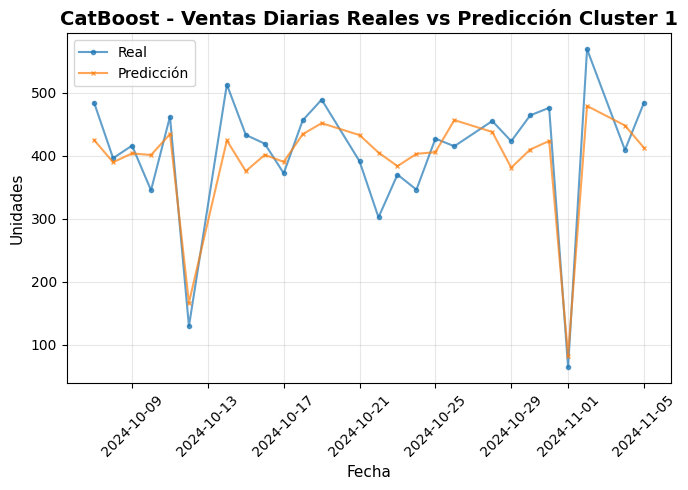


   📌 Producto representativo: 4 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.09
      Error abs medio:          2.91
      Error máximo:            24.38


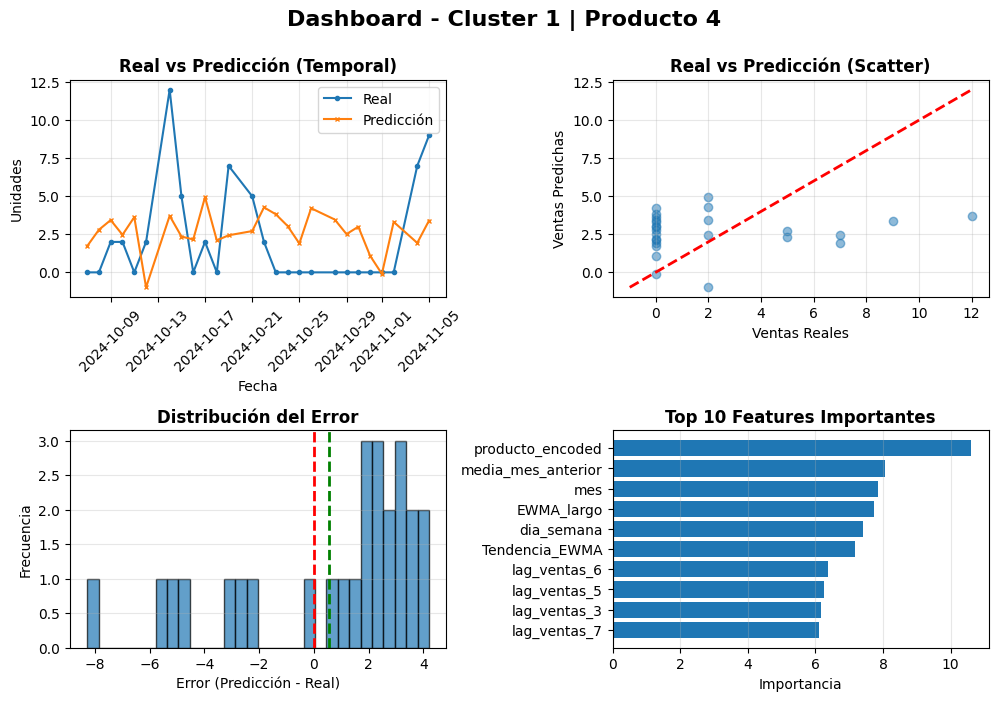


🔄 Entrenando modelo para Cluster 2...
   ✓ MAE: 3.85 | RMSE: 5.30 | R²: 0.1305


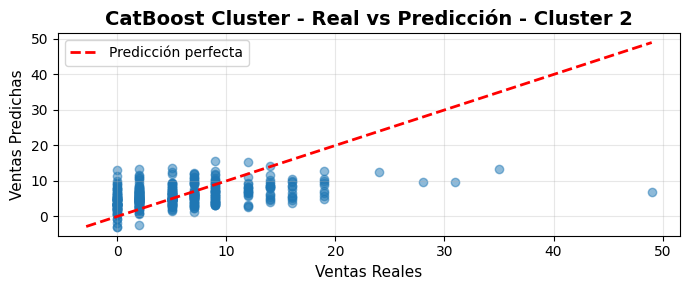

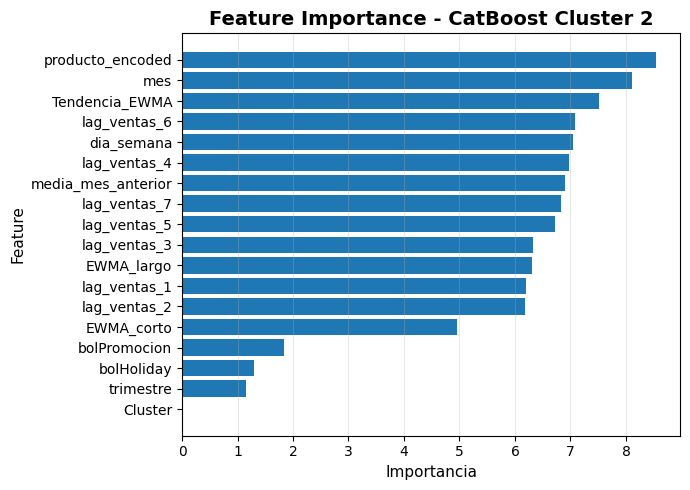

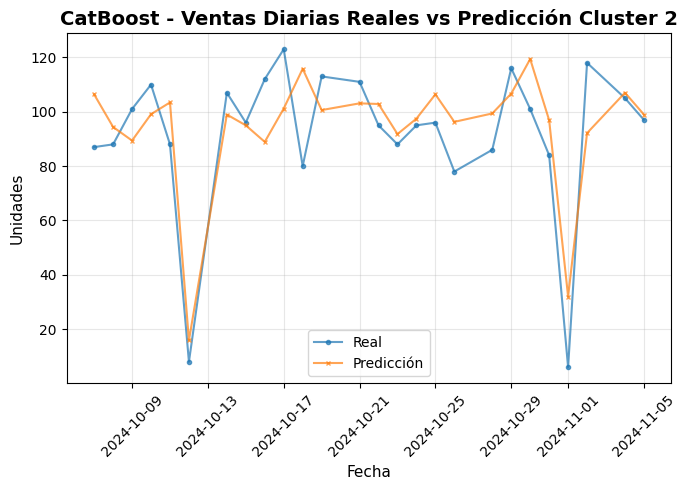


   📌 Producto representativo: 1 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.17
      Error abs medio:          3.85
      Error máximo:            42.06


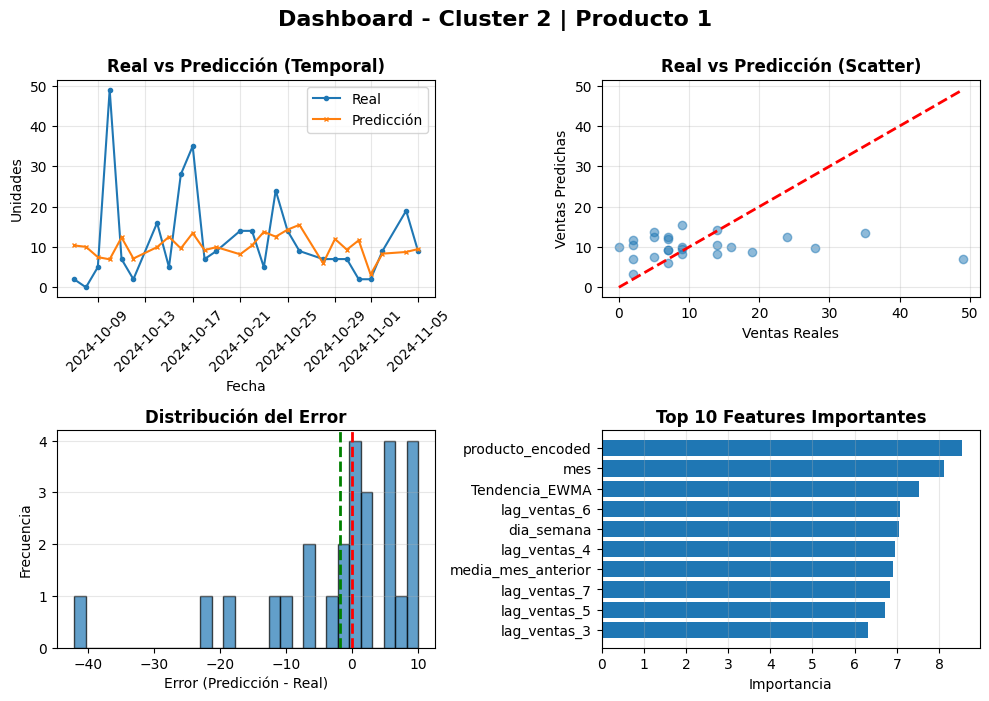


🔄 Entrenando modelo para Cluster 3...
   ✓ MAE: 1.10 | RMSE: 1.72 | R²: 0.0044


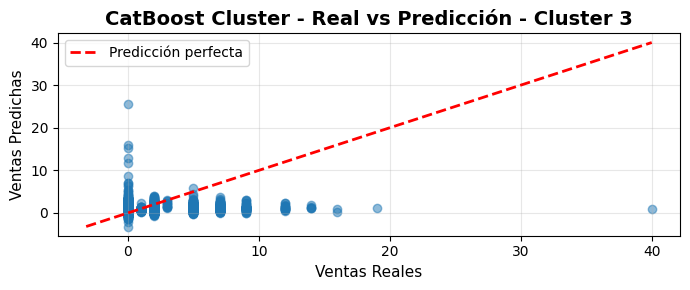

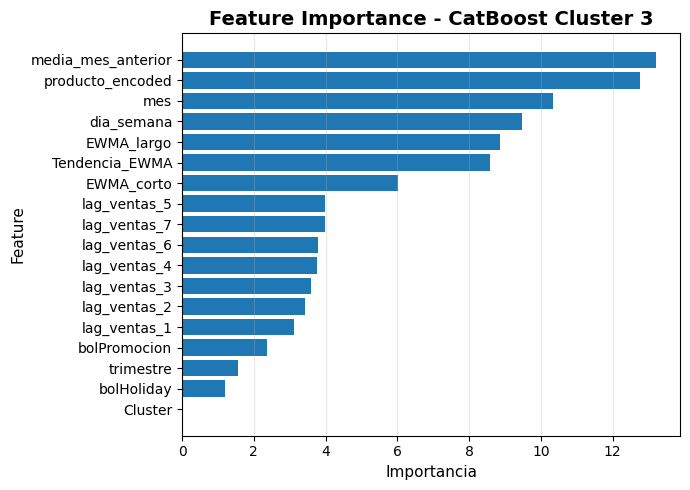

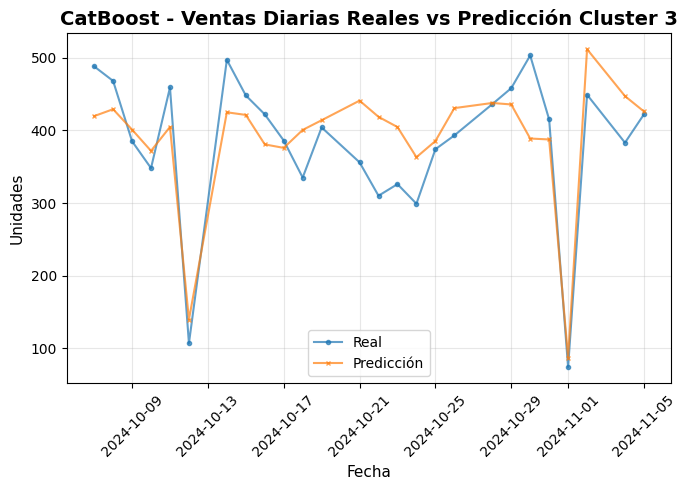


   📌 Producto representativo: 38 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.02
      Error abs medio:          1.10
      Error máximo:            39.00


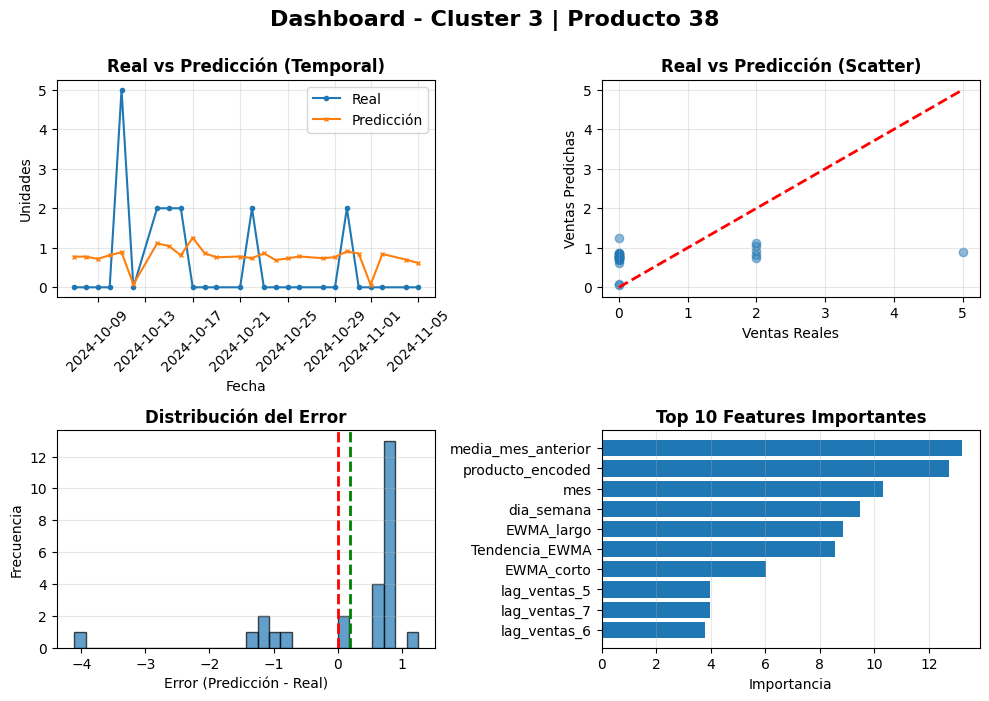

In [12]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: CATBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    catboost_cluster = CatBoostRegressor(**best_params)
    
    catboost_cluster.fit(X_train_c, y_train_c, verbose=False)
    y_pred_c = catboost_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"CatBoost Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    print(f"   ✓ MAE: {metricas_cluster['MAE']:.2f} | RMSE: {metricas_cluster['RMSE']:.2f} | R²: {metricas_cluster['R2']:.4f}")
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz['error'] = y_pred_c - df_test_viz[TARGET]

    grafico_scatter_prediccion(
        df=df_test_viz,
        col_real=TARGET,
        col_pred='prediccion',
        titulo=f'CatBoost Cluster - Real vs Predicción - Cluster {cluster}',
        figsize=(7, 3)
    )

    grafico_feature_importance(
        modelo=catboost_cluster,
        feature_names=FEATURES,
        top_n=len(FEATURES),
        titulo=f'Feature Importance - CatBoost Cluster {cluster}',
        figsize=(7, 5)
    )

    # Crear dataframe con suma por día
    df_daily = df_test_viz.copy()
    df_daily['fecha'] = df_daily['idSecuencia'].dt.date
    df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
    grafico_real_vs_prediccion(
        df=df_daily_sum,
        col_real=TARGET,
        col_pred='prediccion',
        col_fecha='fecha',
        titulo=f'CatBoost - Ventas Diarias Reales vs Predicción Cluster {cluster}',
        figsize=(7, 5)
    )
    
    # Preparar datos para visualización de producto representativo
    test_cluster_pred = test_cluster.copy()
    test_cluster_pred['prediccion'] = y_pred_c
    test_cluster_pred['error'] = y_pred_c - test_cluster_pred[TARGET]
    test_cluster_pred['error_abs'] = np.abs(test_cluster_pred['error'])
    
    # Seleccionar producto representativo
    producto_rep = test_cluster['producto'].value_counts().index[0]
    df_producto = test_cluster_pred[test_cluster_pred['producto'] == producto_rep].copy()
    df_producto = df_producto.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto representativo: {producto_rep} ({len(df_producto)} registros)")
    
    # Estadísticas
    print(f"   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_cluster_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_cluster_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_cluster_pred['error_abs'].max():>8.2f}")
    
    dashboard_prediccion(
        df=df_producto,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=catboost_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster} | Producto {producto_rep}',
        figsize=(10, 7)
    )



🔍 MODELO 3: CATBOOST POR PRODUCTO (TOP 10)

🏆 Top 10 productos: [1, 2, 9, 78, 7, 13, 15, 391, 3, 131]

🔄 Entrenando modelo para Producto 1...
   ✓ MAE: 7.78 | RMSE: 11.48 | R²: -0.0616

   📌 Producto 1
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2    9.595552 7.595552   7.595552
    2024-10-08         0    6.335505 6.335505   6.335505
    2024-10-09         5    8.457790 3.457790   3.457790

   📊 Estadísticas del error:
      Error medio:             -2.02
      Error abs medio:          7.78
      Error máximo:            38.56
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 1 7.7754 131.7206 11.477 -0.0616     98.18      70.16 0.7226    65.85

🏆 Mejor modelo: CatBoost Producto 1 (RMSE: 11.4770)


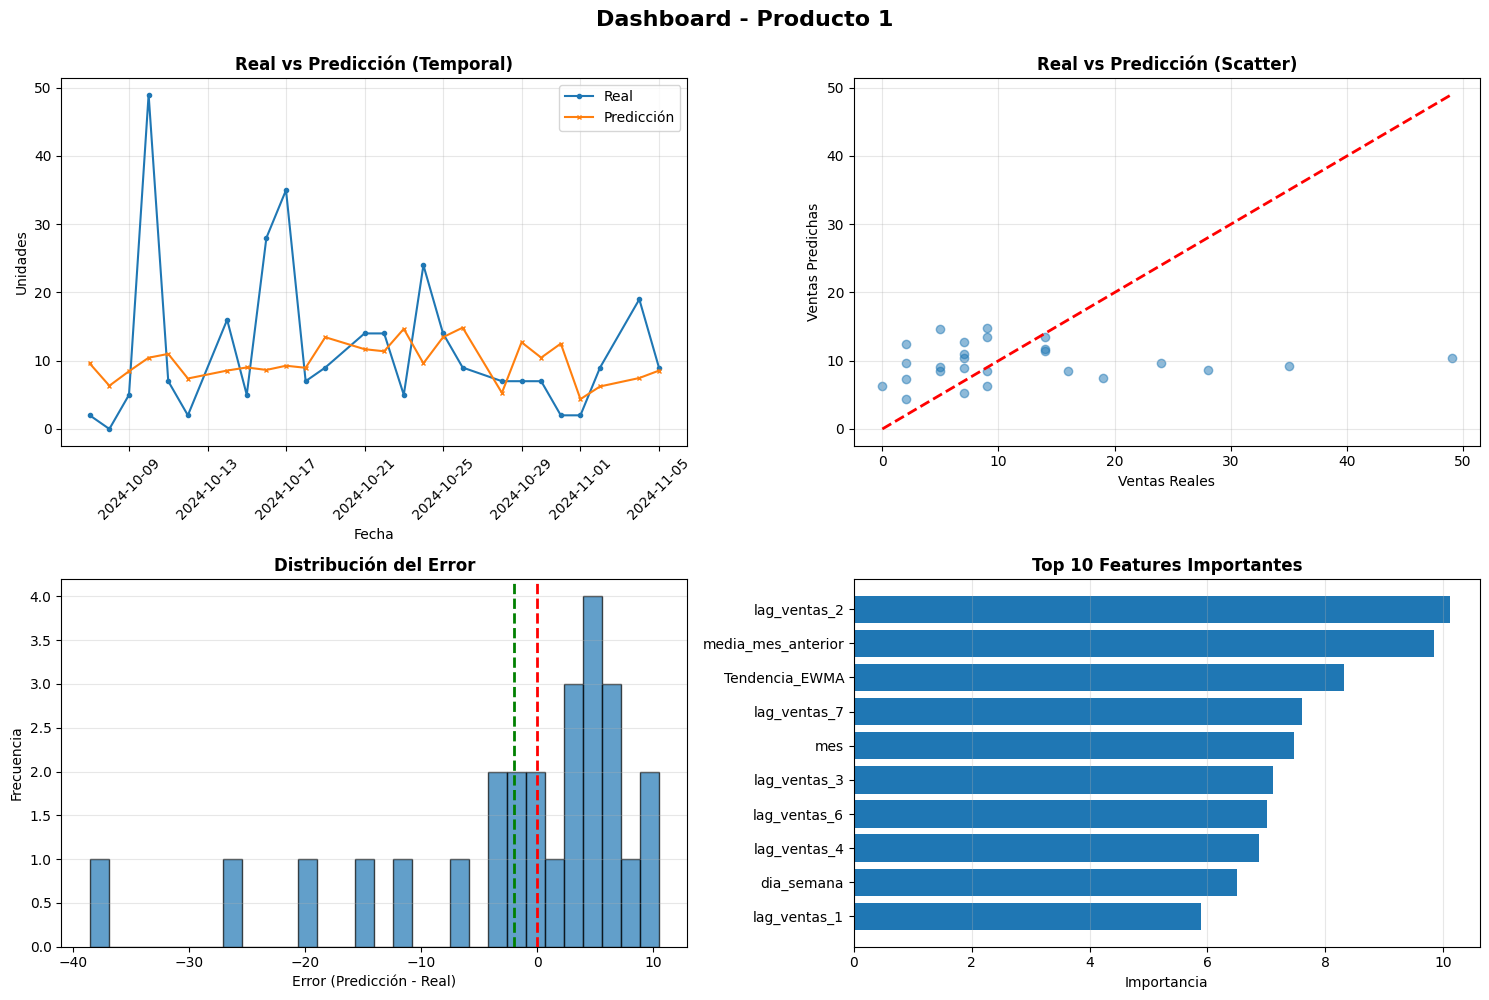


🔄 Entrenando modelo para Producto 2...
   ✓ MAE: 4.14 | RMSE: 4.95 | R²: -0.1961

   📌 Producto 2
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    6.624741 -0.375259   0.375259
    2024-10-08         7    4.196078 -2.803922   2.803922
    2024-10-09        16    7.219726 -8.780274   8.780274

   📊 Estadísticas del error:
      Error medio:              0.79
      Error abs medio:          4.14
      Error máximo:             9.57
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 2 4.1402 24.4534 4.945 -0.1961     92.57      73.88 0.6871    65.64

🏆 Mejor modelo: CatBoost Producto 2 (RMSE: 4.9450)


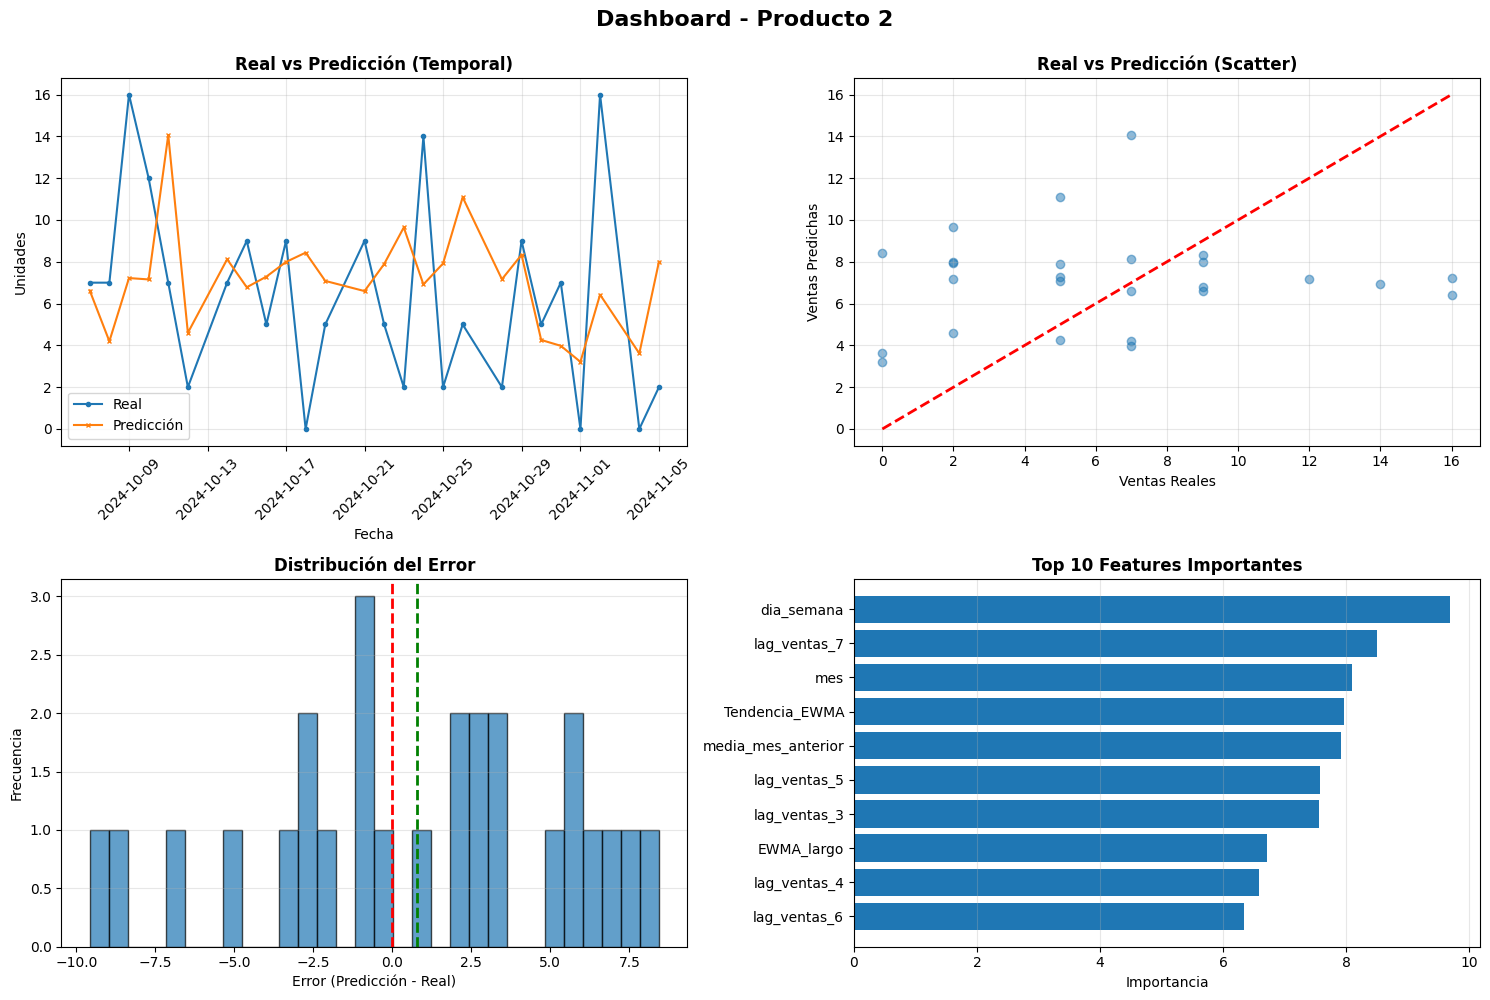


🔄 Entrenando modelo para Producto 9...
   ✓ MAE: 5.19 | RMSE: 5.86 | R²: -0.1144

   📌 Producto 9
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    7.382193 -1.617807   1.617807
    2024-10-08         2   10.128132  8.128132   8.128132
    2024-10-09         5    8.649951  3.649951   3.649951

   📊 Estadísticas del error:
      Error medio:              1.25
      Error abs medio:          5.19
      Error máximo:            12.22
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 9 5.1889 34.3028 5.8569 -0.1144    134.49      90.86 0.7824    80.78

🏆 Mejor modelo: CatBoost Producto 9 (RMSE: 5.8569)


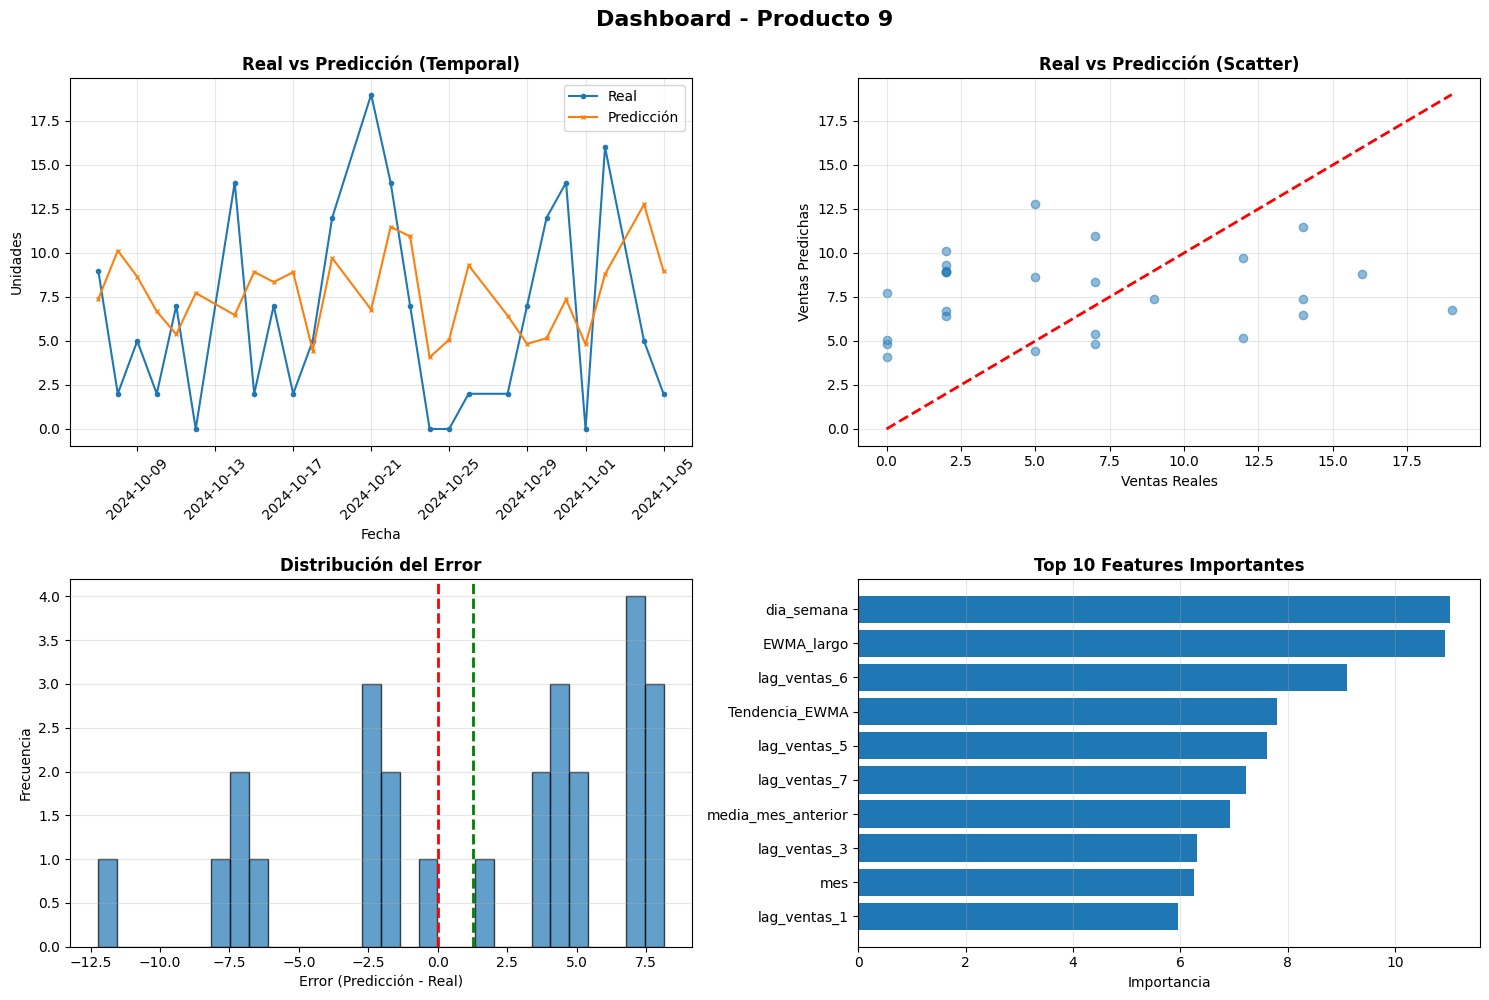


🔄 Entrenando modelo para Producto 78...
   ✓ MAE: 5.06 | RMSE: 6.38 | R²: 0.2074

   📌 Producto 78
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion      error  error_abs
    2024-10-07        16   12.165264  -3.834736   3.834736
    2024-10-08        16    5.603485 -10.396515  10.396515
    2024-10-09        14   10.826970  -3.173030   3.173030

   📊 Estadísticas del error:
      Error medio:             -1.36
      Error abs medio:          5.06
      Error máximo:            19.81
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 78 5.0641 40.6542 6.3761 0.2074     62.52      63.19 0.6343    44.78

🏆 Mejor modelo: CatBoost Producto 78 (RMSE: 6.3761)


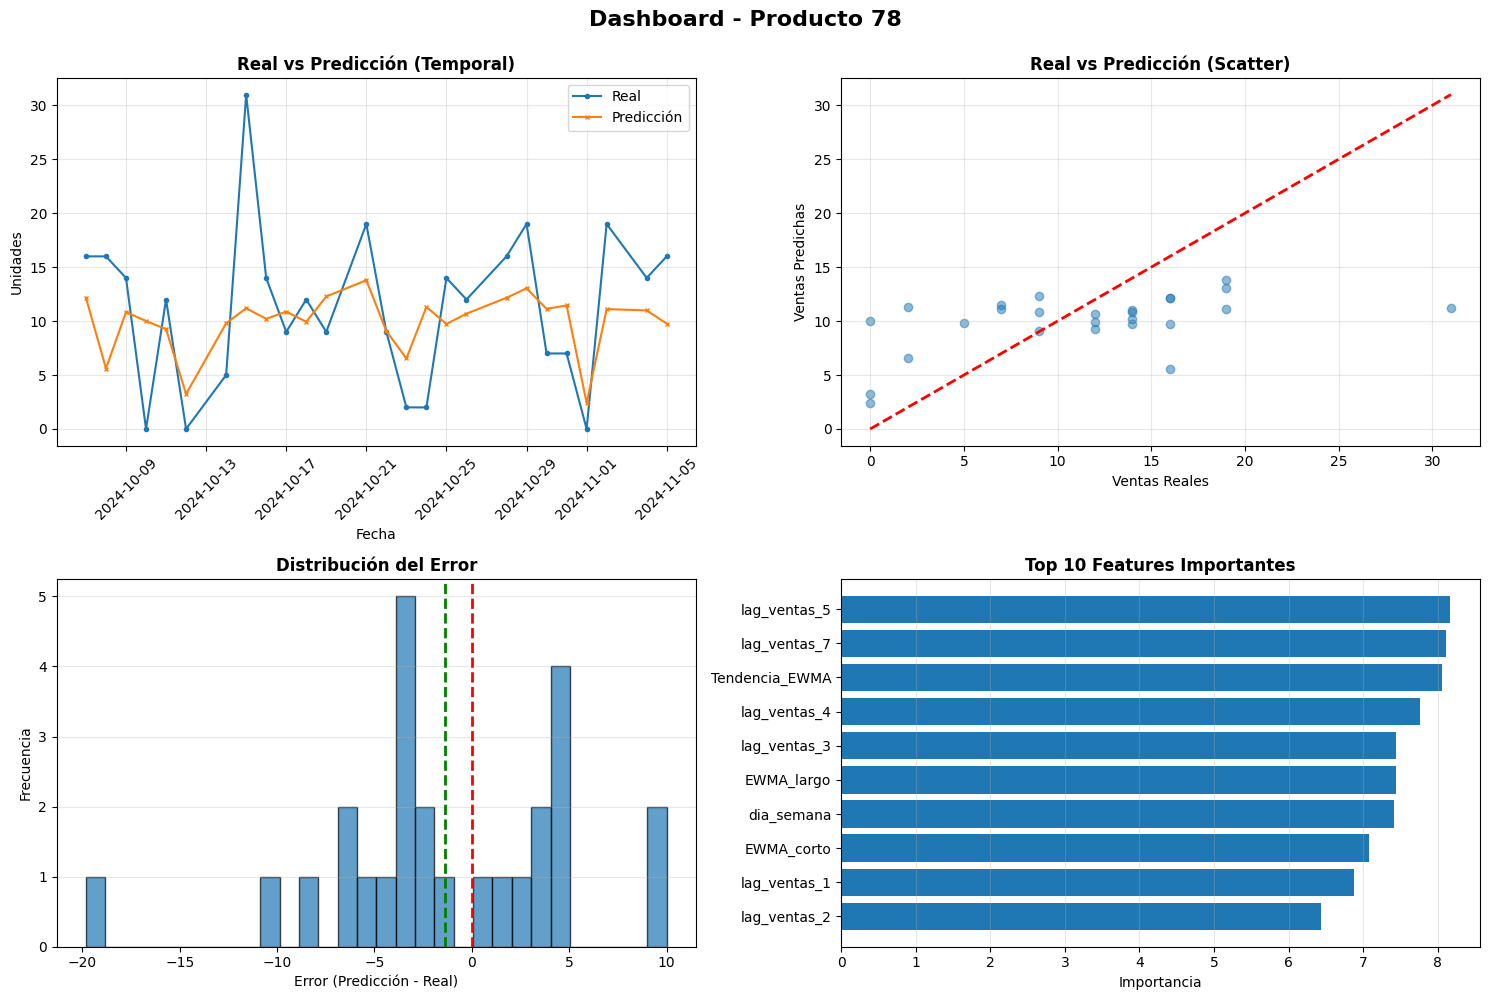


🔄 Entrenando modelo para Producto 7...
   ✓ MAE: 3.80 | RMSE: 4.16 | R²: -1.2448

   📌 Producto 7
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         0    4.834327 4.834327   4.834327
    2024-10-08         0    7.024173 7.024173   7.024173
    2024-10-09         0    6.248307 6.248307   6.248307

   📊 Estadísticas del error:
      Error medio:              2.58
      Error abs medio:          3.80
      Error máximo:             7.02
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 7 3.8003 17.3072 4.1602 -1.2448    113.48     119.67 1.0138   149.71

🏆 Mejor modelo: CatBoost Producto 7 (RMSE: 4.1602)


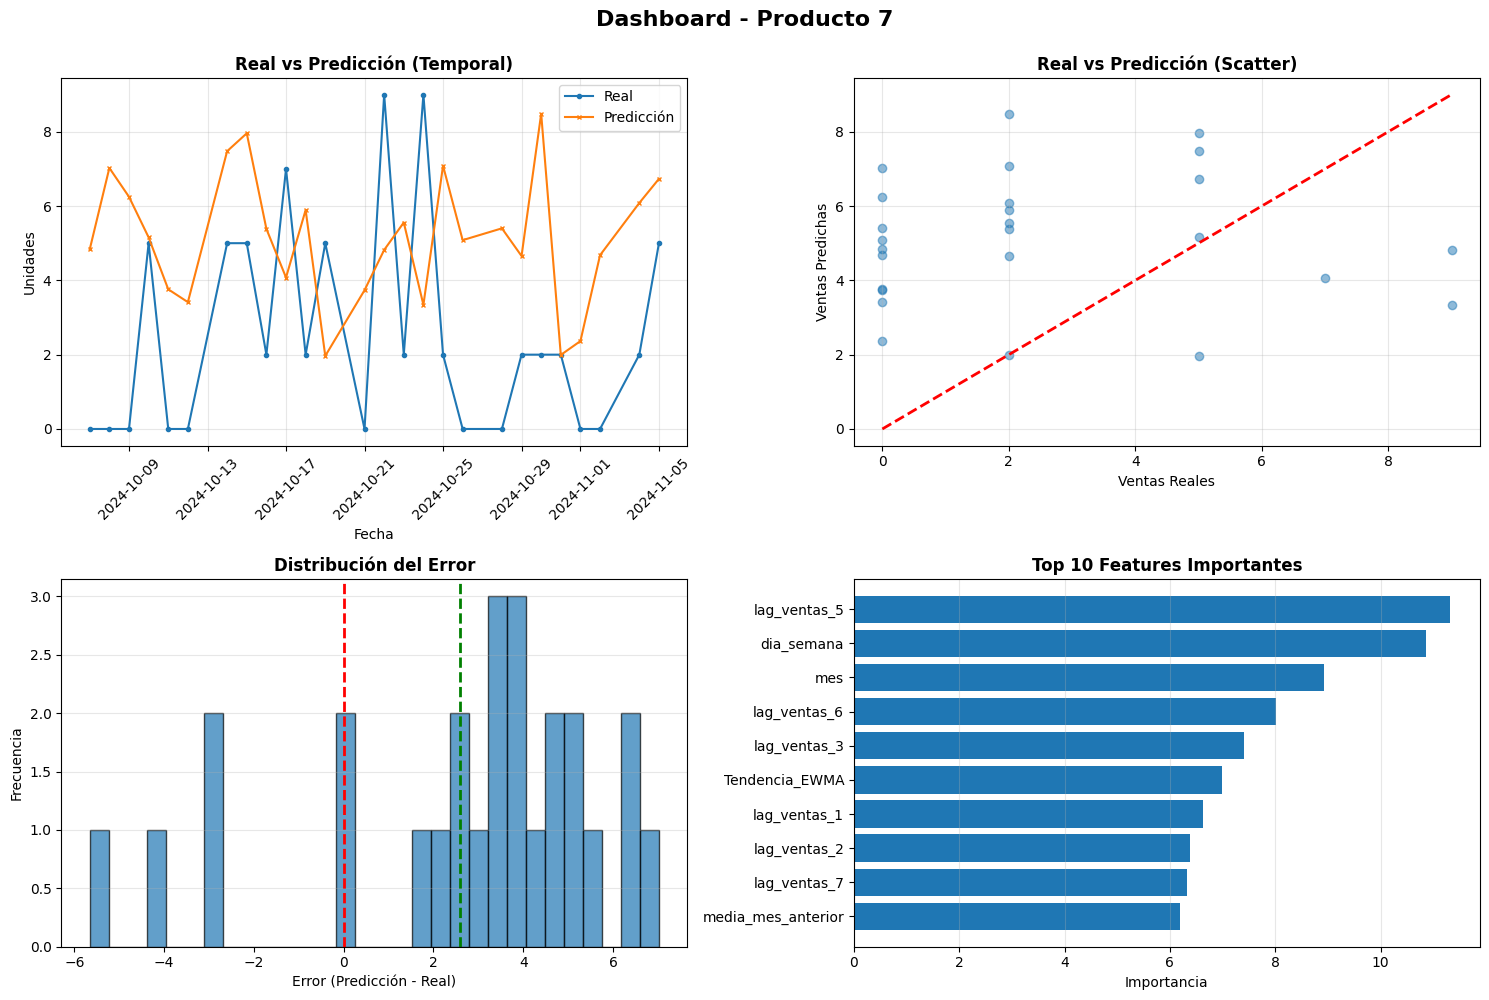


🔄 Entrenando modelo para Producto 13...
   ✓ MAE: 3.05 | RMSE: 3.60 | R²: -0.1215

   📌 Producto 13
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2    6.262728 4.262728   4.262728
    2024-10-08         2    6.574338 4.574338   4.574338
    2024-10-09         2    3.620466 1.620466   1.620466

   📊 Estadísticas del error:
      Error medio:              1.13
      Error abs medio:          3.05
      Error máximo:             7.39
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 13 3.0525 12.9819 3.603 -0.1215     93.58      81.93 0.6888    77.05

🏆 Mejor modelo: CatBoost Producto 13 (RMSE: 3.6030)


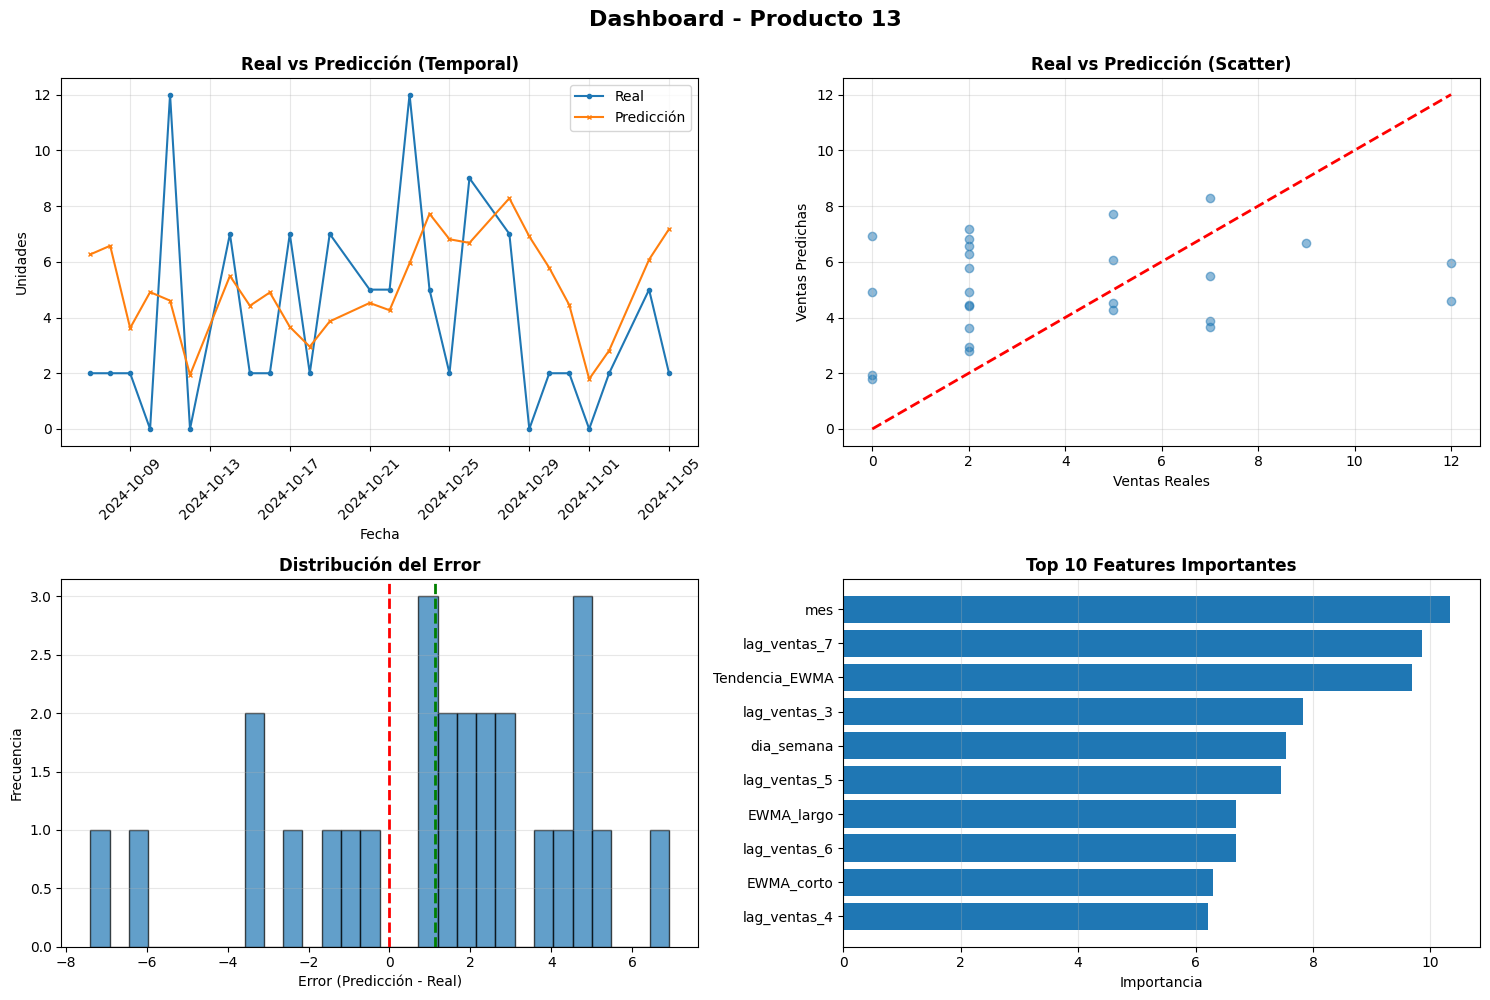


🔄 Entrenando modelo para Producto 15...
   ✓ MAE: 3.18 | RMSE: 3.85 | R²: 0.0726

   📌 Producto 15
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    5.119078 -1.880922   1.880922
    2024-10-08         5    4.482294 -0.517706   0.517706
    2024-10-09         9    4.353479 -4.646521   4.646521

   📊 Estadísticas del error:
      Error medio:             -0.13
      Error abs medio:          3.18
      Error máximo:             8.67
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 15 3.1795 14.8214 3.8499 0.0726     58.86      71.29 0.7376    55.86

🏆 Mejor modelo: CatBoost Producto 15 (RMSE: 3.8499)


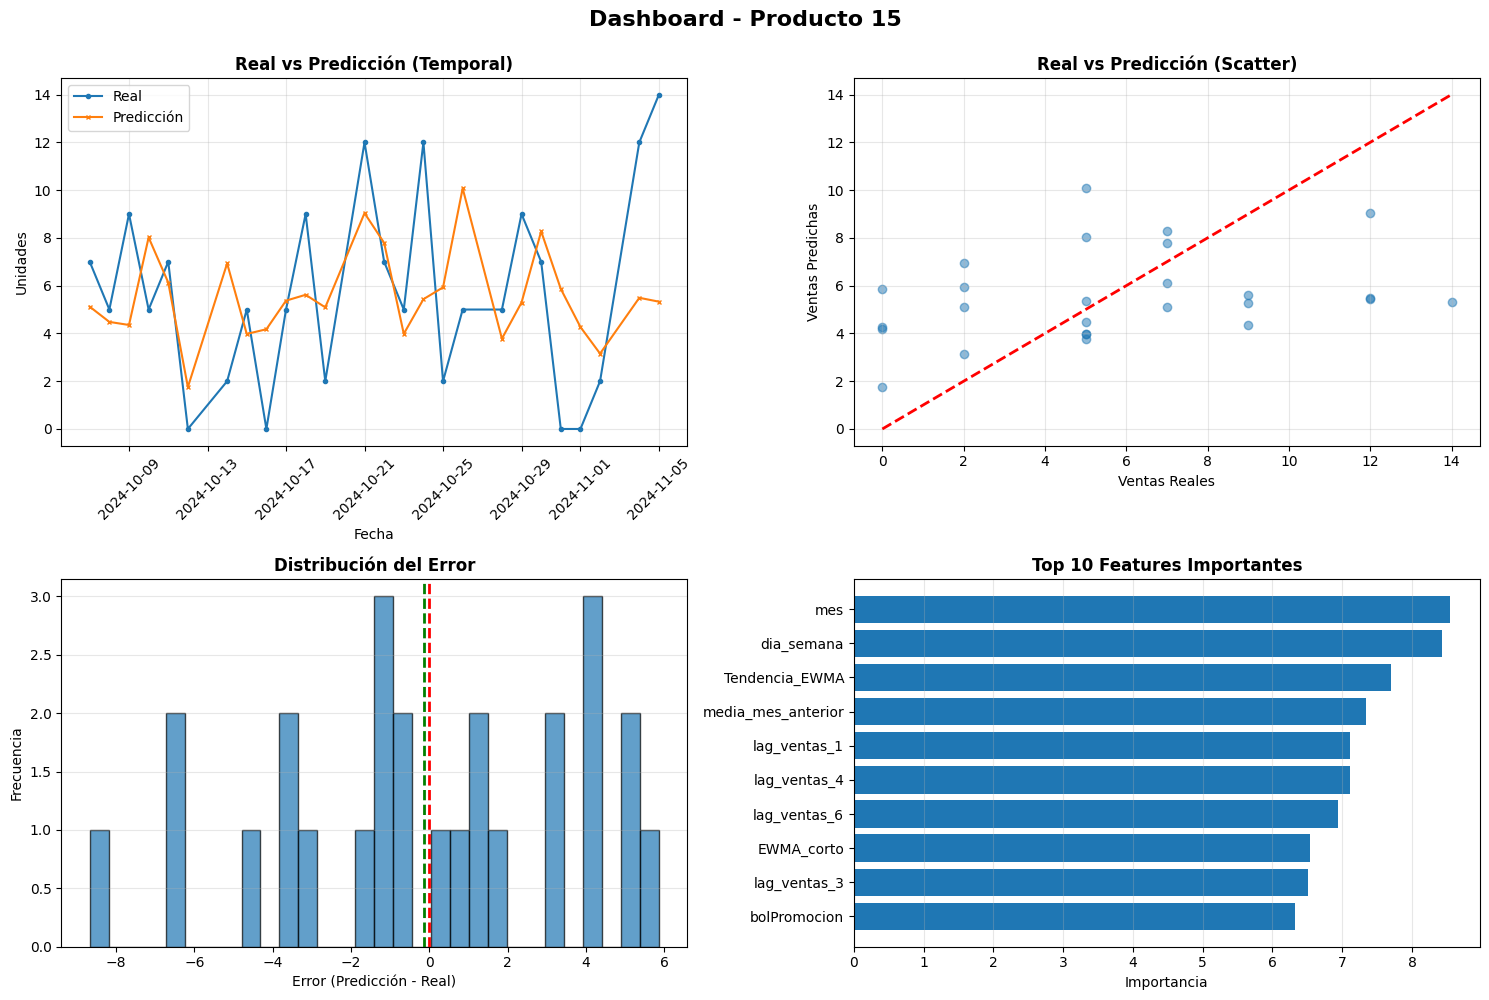


🔄 Entrenando modelo para Producto 391...
   ✓ MAE: 3.36 | RMSE: 4.04 | R²: -0.1525

   📌 Producto 391
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         5    4.998844 -0.001156   0.001156
    2024-10-08         9    6.489817 -2.510183   2.510183
    2024-10-09         0    5.853568  5.853568   5.853568

   📊 Estadísticas del error:
      Error medio:              0.80
      Error abs medio:          3.36
      Error máximo:             9.66
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 391 3.3603 16.3193 4.0397 -0.1525     80.16     112.37 0.7191    99.28

🏆 Mejor modelo: CatBoost Producto 391 (RMSE: 4.0397)


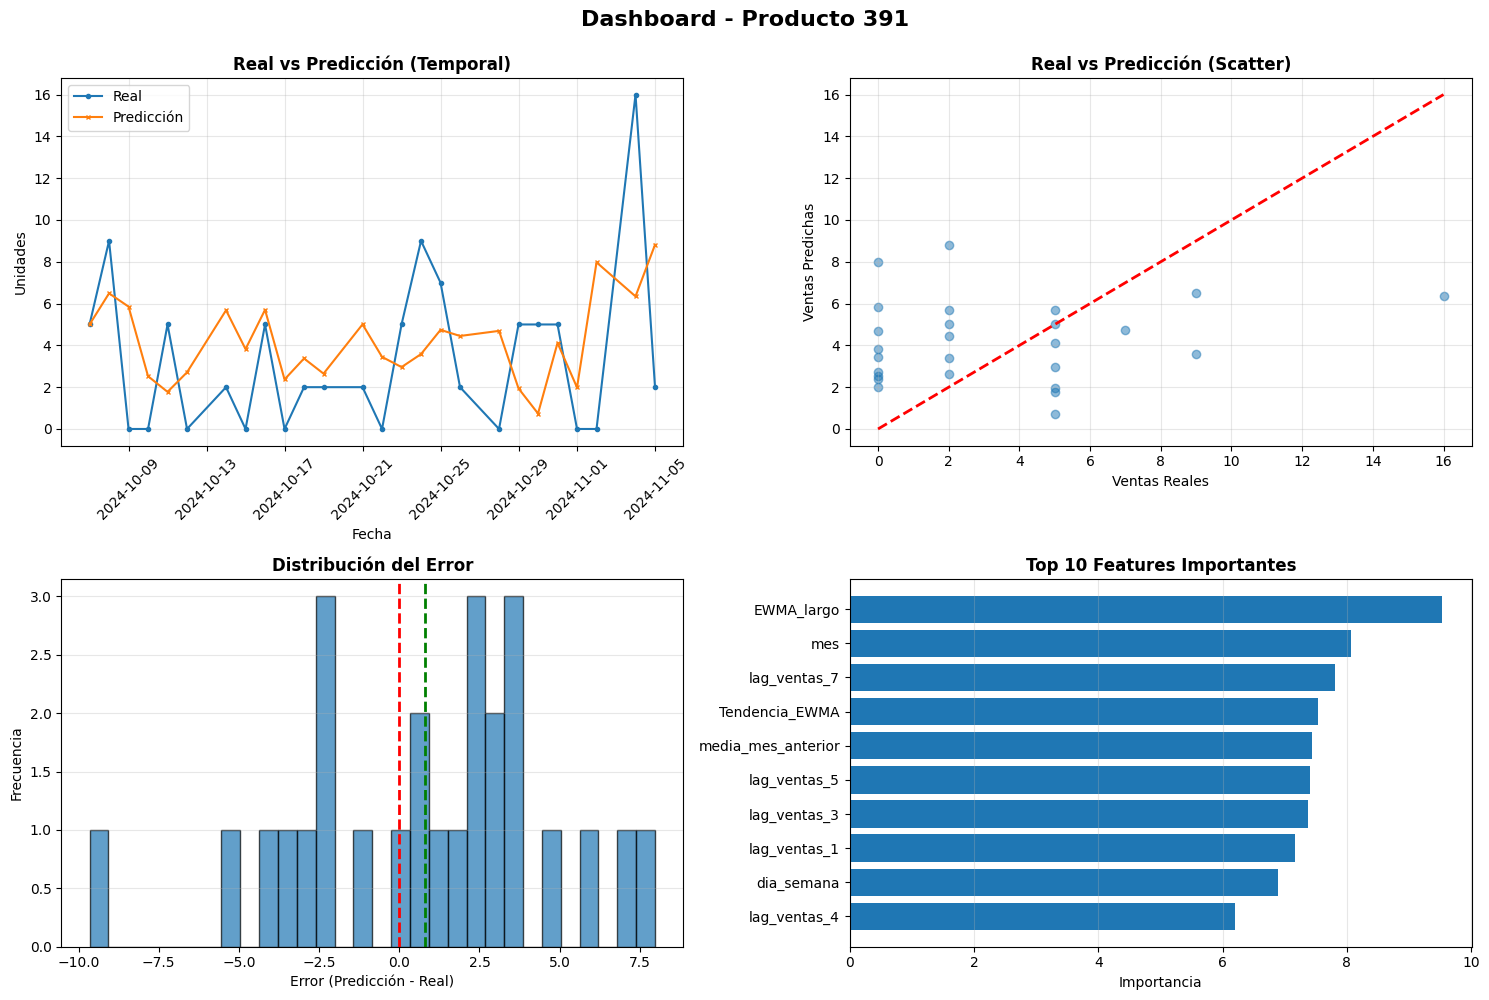


🔄 Entrenando modelo para Producto 3...
   ✓ MAE: 4.52 | RMSE: 5.75 | R²: -0.0892

   📌 Producto 3
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    3.151273 -3.848727   3.848727
    2024-10-08         5    5.238129  0.238129   0.238129
    2024-10-09         5    6.985078  1.985078   1.985078

   📊 Estadísticas del error:
      Error medio:             -0.95
      Error abs medio:          4.52
      Error máximo:            15.63
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto 3 4.5162 33.0264 5.7469 -0.0892     74.64      91.82 0.9742    70.31

🏆 Mejor modelo: CatBoost Producto 3 (RMSE: 5.7469)


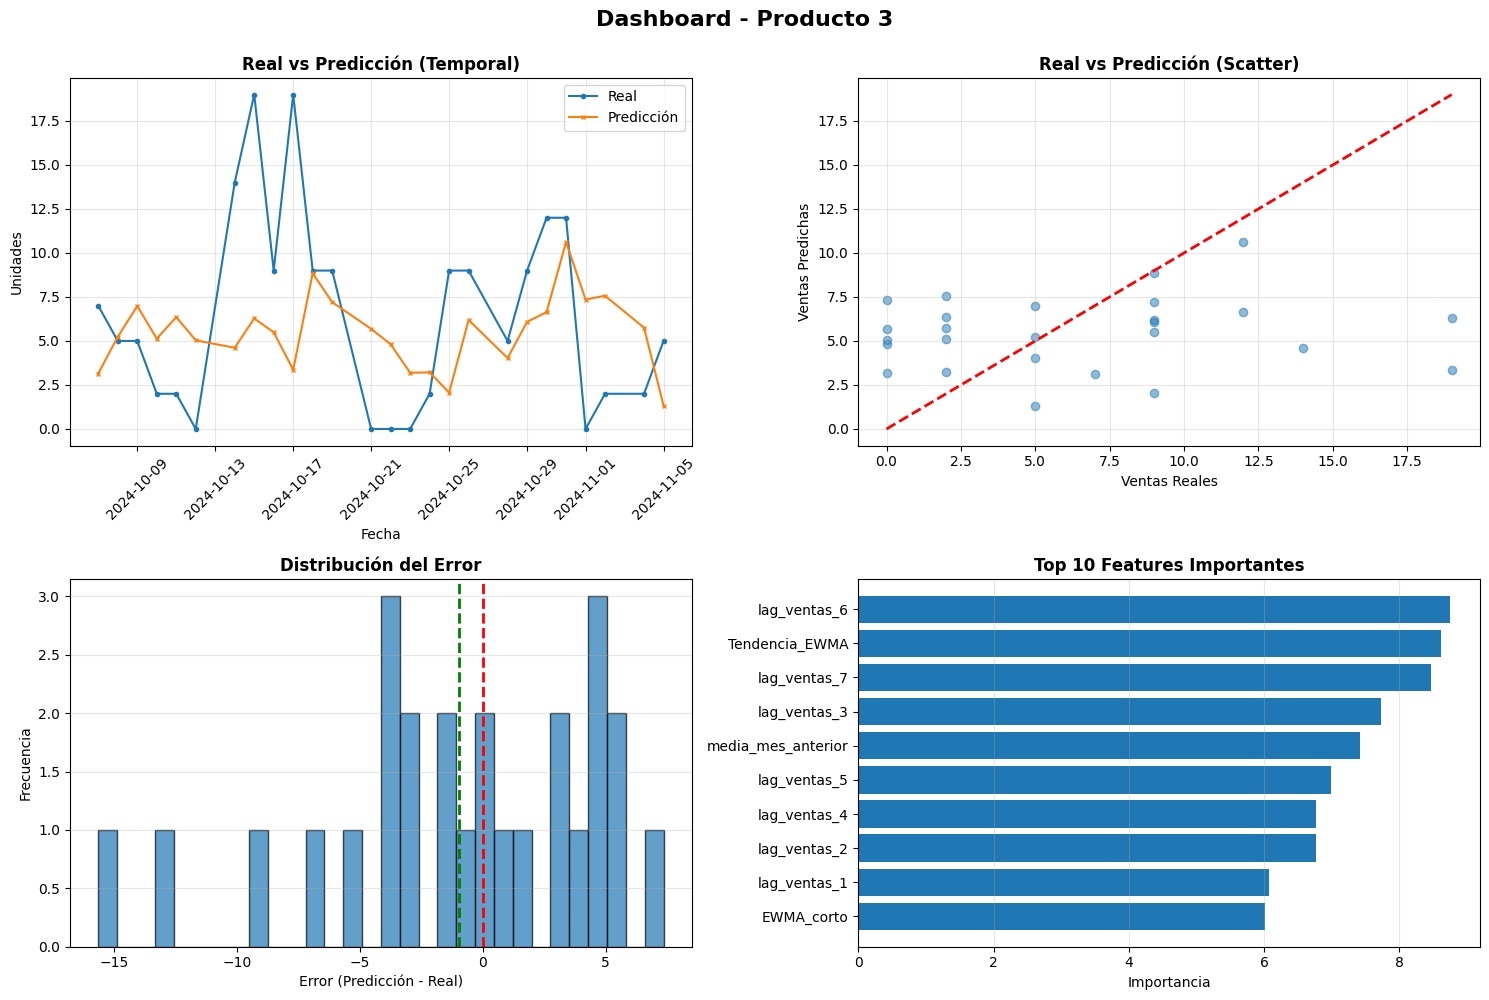


🔄 Entrenando modelo para Producto 131...
   ✓ MAE: 3.23 | RMSE: 3.67 | R²: 0.0945

   📌 Producto 131
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    5.495197 -3.504803   3.504803
    2024-10-08         9    7.431998 -1.568002   1.568002
    2024-10-09         2    8.280351  6.280351   6.280351

   📊 Estadísticas del error:
      Error medio:              0.68
      Error abs medio:          3.23
      Error máximo:             6.28
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 131 3.2266 13.4827 3.6719 0.0945     66.29       99.5 0.7246    86.49

🏆 Mejor modelo: CatBoost Producto 131 (RMSE: 3.6719)


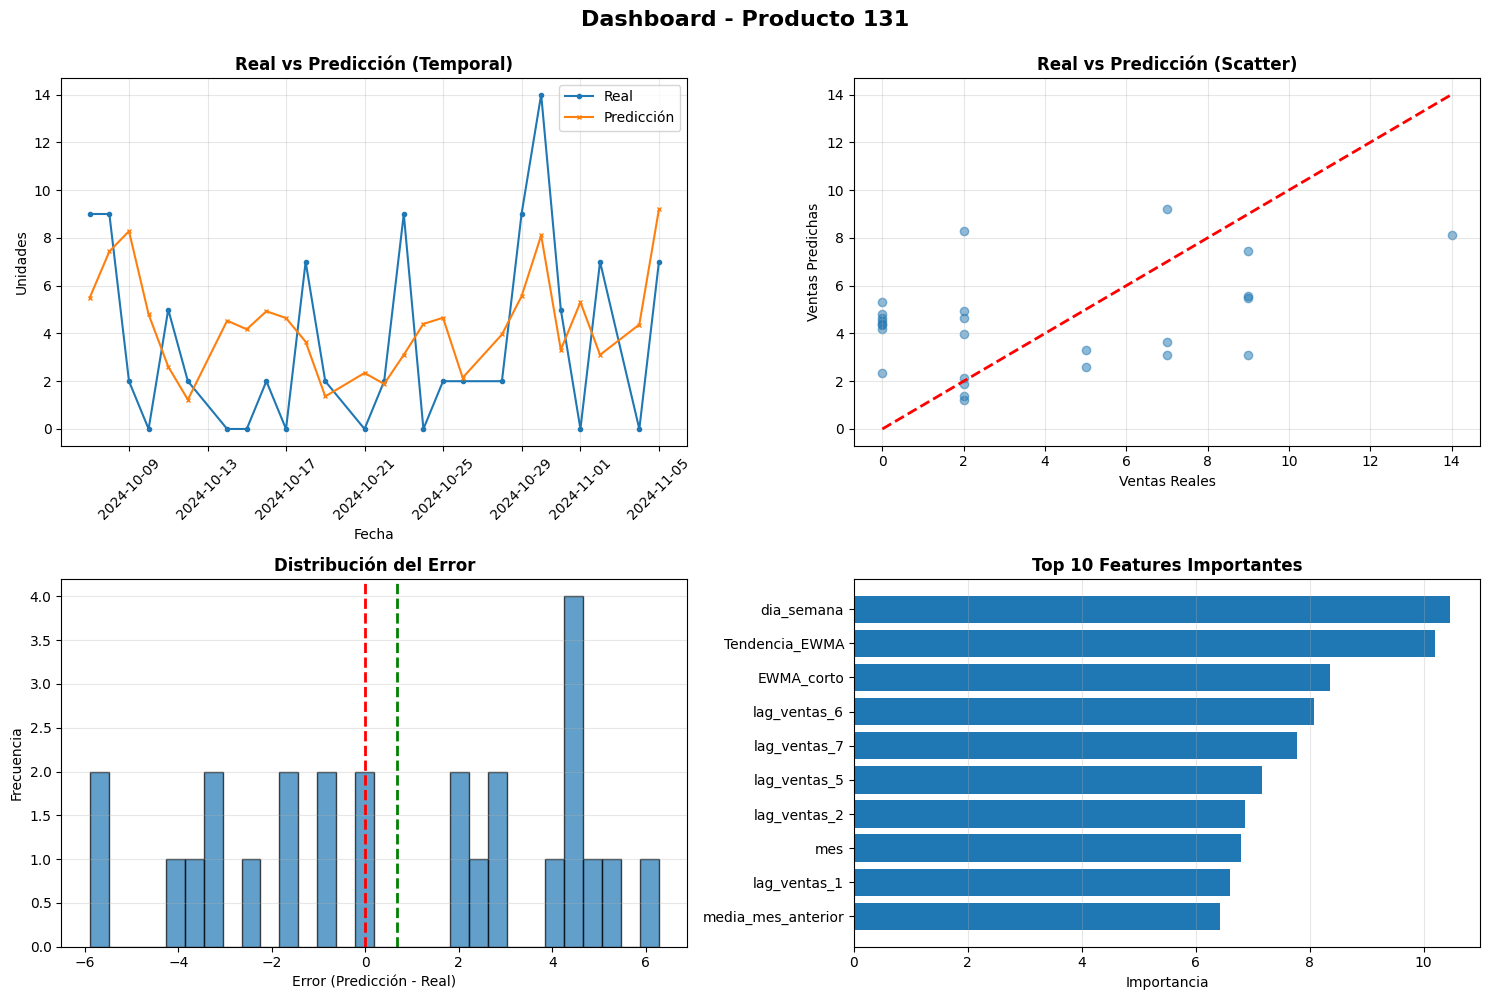

In [13]:

# ============================================================================
# 3. MODELOS POR PRODUCTO (TOP 10)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 3: CATBOOST POR PRODUCTO (TOP 10)")
print("="*100)

top_productos = df_train.groupby('producto')['udsVenta'].sum().nlargest(10).index.tolist()
print(f"\n🏆 Top 10 productos: {top_productos}")

modelos_producto = {}

for producto in top_productos:
    print(f"\n🔄 Entrenando modelo para Producto {producto}...")
    
    # Filtrar datos
    train_prod = df_train[df_train['producto'] == producto]
    test_prod = df_test[df_test['producto'] == producto].dropna()
    
    if len(test_prod) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    if len(train_prod) < 100:
        print(f"   ⚠️  Datos insuficientes ({len(train_prod)} registros)")
        continue
    
    X_train_p = train_prod[FEATURES]
    y_train_p = train_prod[TARGET]
    X_test_p = test_prod[FEATURES]
    y_test_p = test_prod[TARGET]
    
    # Entrenar
    catboost_producto = CatBoostRegressor(**best_params)
    
    catboost_producto.fit(X_train_p, y_train_p, verbose=False)
    y_pred_p = catboost_producto.predict(X_test_p)
    
    modelos_producto[producto] = catboost_producto
    
    # Calcular métricas
    metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"CatBoost Producto {producto}")
    todas_metricas.append(metricas_producto)
    
    print(f"   ✓ MAE: {metricas_producto['MAE']:.2f} | RMSE: {metricas_producto['RMSE']:.2f} | R²: {metricas_producto['R2']:.4f}")
    
    # Preparar datos
    test_prod_pred = test_prod.copy()
    test_prod_pred['prediccion'] = y_pred_p
    test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
    test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
    test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / test_prod_pred[TARGET]) * 100
    test_prod_pred = test_prod_pred.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto {producto}")
    print(f"      Train: {len(train_prod)} | Test: {len(test_prod_pred)}")
    
    # Primeras predicciones
    print(f"\n   📋 Primeras 3 predicciones:")
    cols = ['idSecuencia', TARGET, 'prediccion', 'error', 'error_abs']
    print("   " + test_prod_pred[cols].head(3).to_string(index=False).replace('\n', '\n   '))
    
    # Estadísticas
    print(f"\n   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_prod_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_prod_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_prod_pred['error_abs'].max():>8.2f}")
    print(f"      Error % medio:        {test_prod_pred['error_pct'].mean():>8.2f}%")
    
    if len(test_prod_pred) >= 2:
        resumen_metricas([metricas_producto])
        
        try:
            dashboard_prediccion(
                df=test_prod_pred,
                col_fecha='idSecuencia',
                col_real=TARGET,
                col_pred='prediccion',
                modelo=catboost_producto,
                feature_names=FEATURES,
                titulo_principal=f'Dashboard - Producto {producto}',
                figsize=(15, 10),
            )
        except Exception as e:
            print(f"   ⚠️  Error en dashboard: {str(e)}")



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   CatBoost Cluster 3 1.0985   2.9713  1.7237  0.0044     57.01     169.93 0.7735   135.26
 CatBoost Global Test 1.5821   5.8072  2.4098  0.2422     50.62     145.17 0.7385    96.89
   CatBoost Cluster 0 1.8396   6.7013  2.5887  0.0896     43.18     127.91 0.7442    95.28
 CatBoost Producto 13 3.0525  12.9819  3.6030 -0.1215     93.58      81.93 0.6888    77.05
CatBoost Producto 131 3.2266  13.4827  3.6719  0.0945     66.29      99.50 0.7246    86.49
   CatBoost Cluster 1 2.9070  14.2080  3.7694  0.0550     59.78     101.47 0.7534    76.24
 CatBoost Producto 15 3.1795  14.8214  3.8499  0.0726     58.86      71.29 0.7376    55.86
CatBoost Producto 391 3.3603  16.3193  4.0397 -0.1525     80.16     112.37 0.7191    99.28
  CatBoost Producto 7 3.8003  17.3072  4.1602 -1.2448    113.48     119.

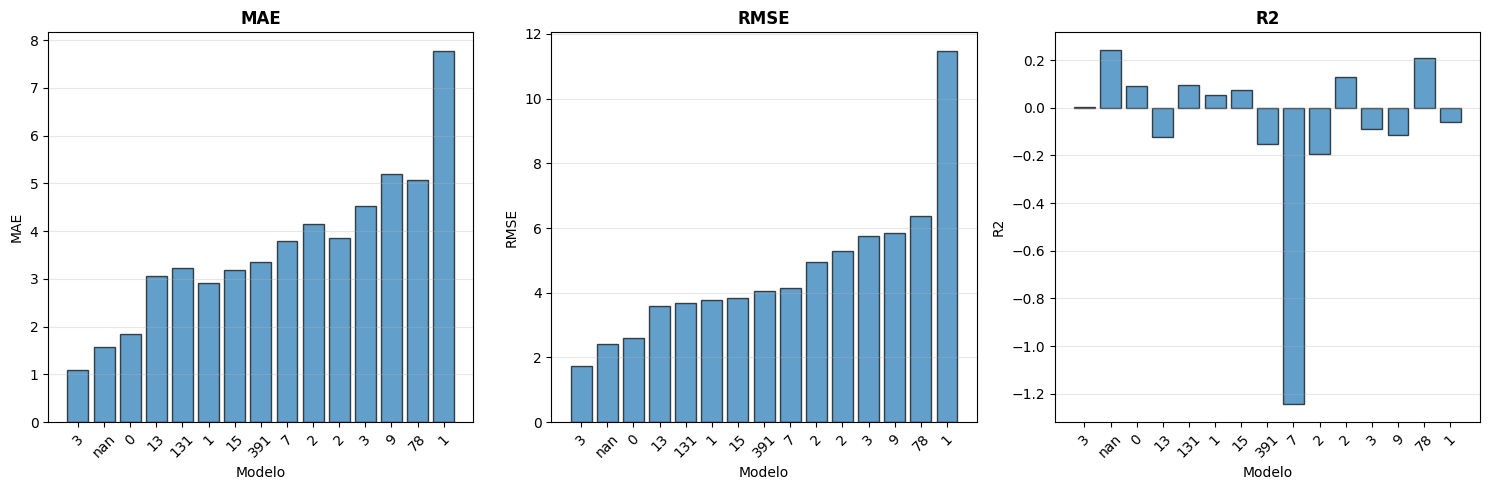


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌍 MODELOS GLOBALES:
           Algoritmo    MAE   RMSE     R2
CatBoost Global Test 1.5821 2.4098 0.2422

   Promedio RMSE: 2.41

🎯 MODELOS POR CLUSTER:
         Algoritmo    MAE   RMSE     R2
CatBoost Cluster 3 1.0985 1.7237 0.0044
CatBoost Cluster 0 1.8396 2.5887 0.0896
CatBoost Cluster 1 2.9070 3.7694 0.0550
CatBoost Cluster 2 3.8505 5.3044 0.1305

   Promedio RMSE: 3.35
   Mejor cluster: CatBoost Cluster 3 (RMSE: 1.72)
   Peor cluster: CatBoost Cluster 2 (RMSE: 5.30)

🛒 MODELOS POR PRODUCTO:
            Algoritmo    MAE    RMSE      R2
 CatBoost Producto 13 3.0525  3.6030 -0.1215
CatBoost Producto 131 3.2266  3.6719  0.0945
 CatBoost Producto 15 3.1795  3.8499  0.0726
CatBoost Producto 391 3.3603  4.0397 -0.1525
  CatBoost Producto 7 3.8003  4.1602 -1.2448
  CatBoost Producto 2 4.1402  4.9450 -0.1961
  CatBoost Producto 3 4.5162  5.7469 -0.0892
  CatBoost Producto 9 5.1889  5.8569 -0.1144
 CatBoost Producto 78 5.0641  6.3761  0.2074
  CatBoost 

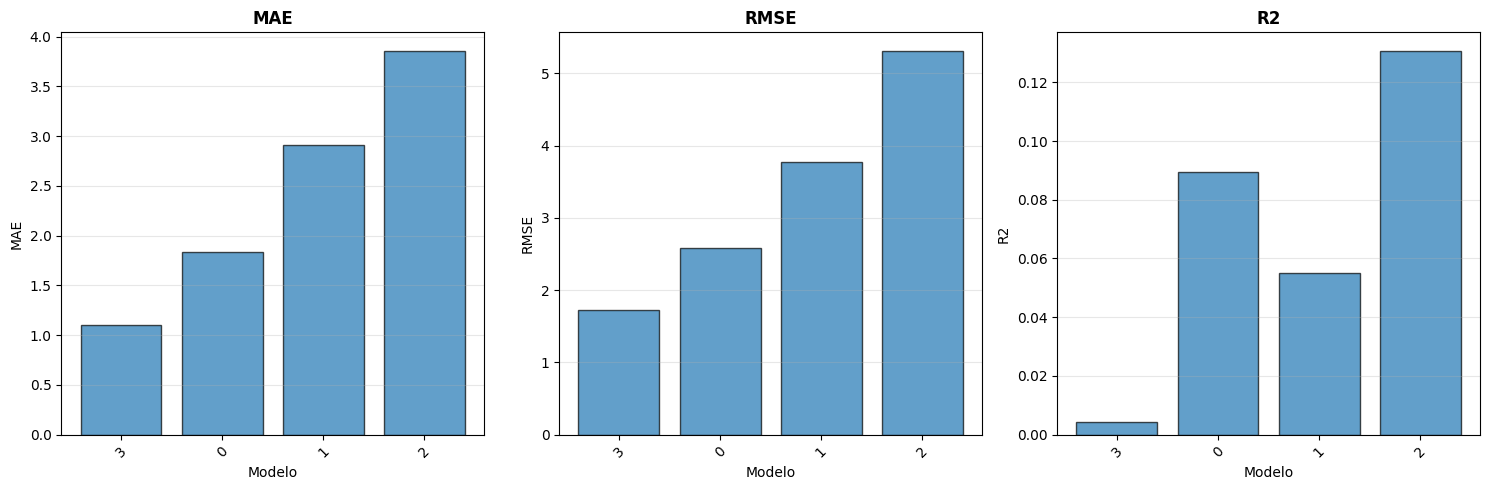


📊 Comparación entre productos:


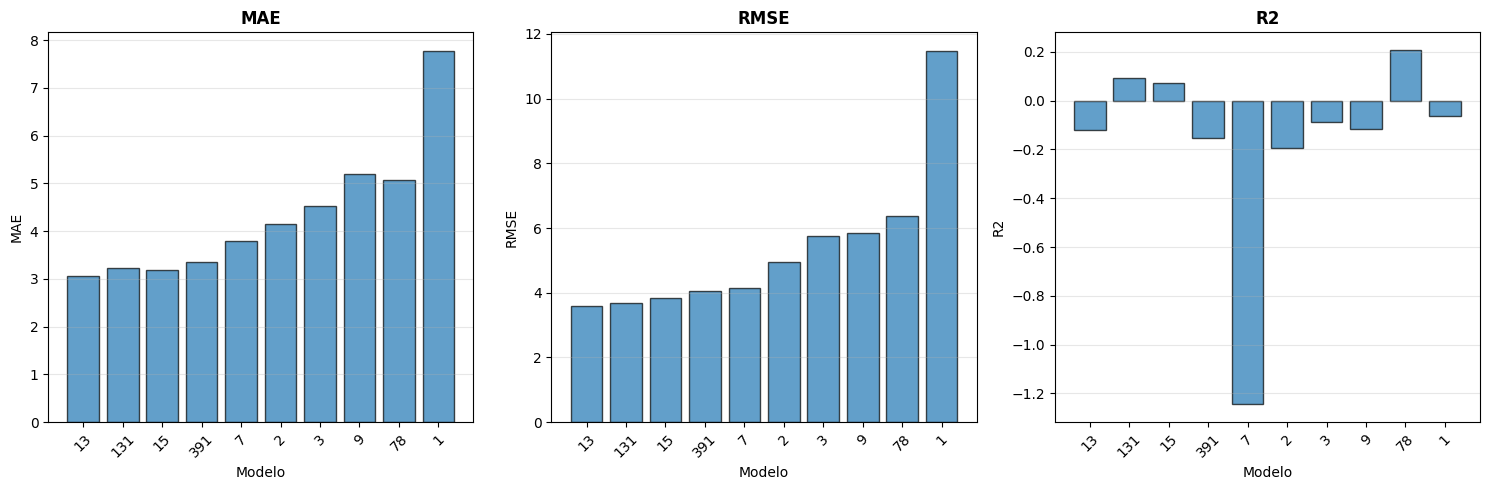


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 15
   - Modelos globales: 1
   - Modelos por cluster: 4
   - Modelos por producto: 10


In [14]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌍 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")


In [15]:

# Salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_catboost.csv', index=False)
print("\nResultados guardados en 'datos/resultados_metricas_catboost.csv'")


Resultados guardados en 'datos/resultados_metricas_catboost.csv'


# CatBoost por Cluster

# CatBoost por top 10 productos de ventas

# Resumen final

# Salvar resultados